In [1]:
from src.preprocessing import *
from src.sdt import SDT
from src.dbdt import DBDT_SGD

ModuleNotFoundError: No module named 'src'

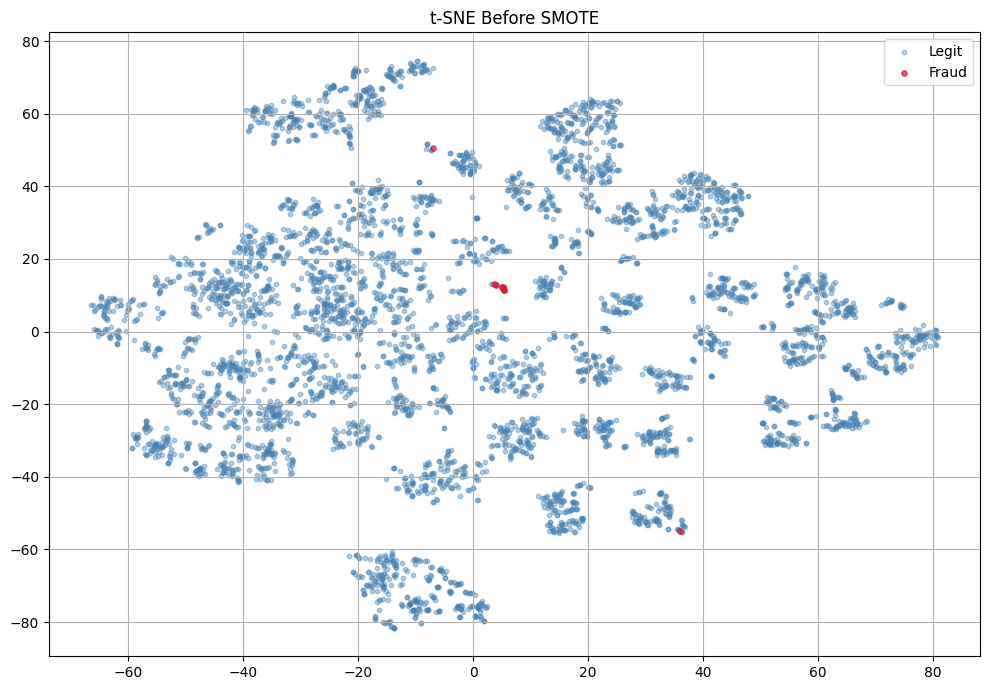

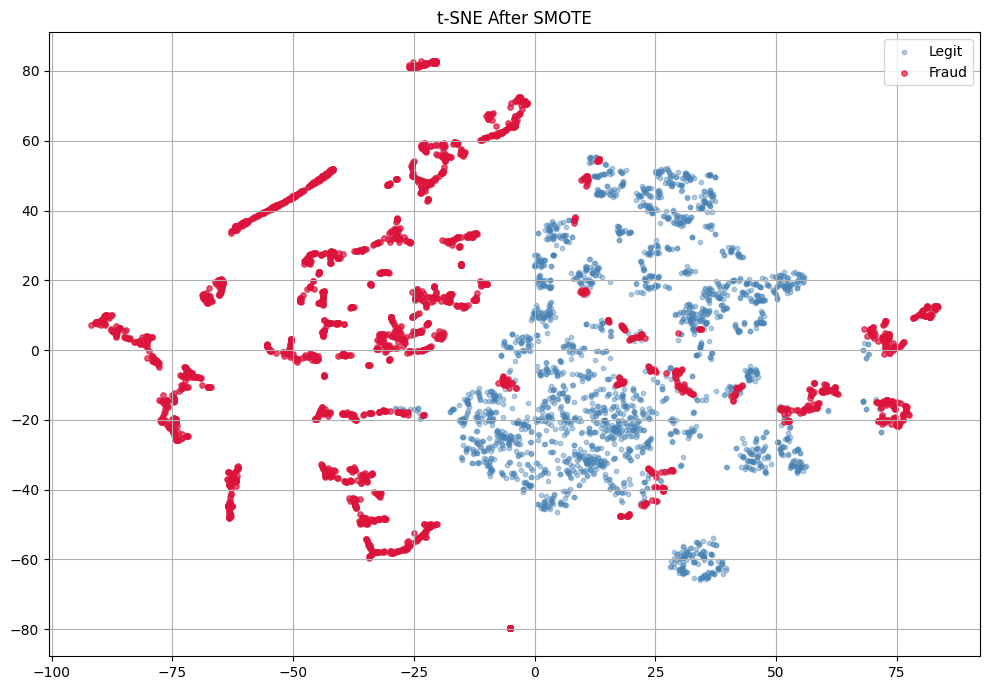

Before SMOTE: {np.int64(-1): np.int64(231), np.int64(1): np.int64(141993)}
After SMOTE: {np.int64(-1): np.int64(231), np.int64(1): np.int64(141993)}


In [ ]:


X, y = load_data()
X_train, X_test, y_train, y_test = test_train_split(X, y)
X_train, X_val, y_train, y_val = train_valid_split(X_train, y_train)
X_train, y_train = interquatile_range(X_train, y_train)
unique_before, counts_before = np.unique(y_train, return_counts=True)
X_train_resampled, y_train_resampled = apply_smote(X_train, y_train)

plot_tsne(X=X_train, y=y_train, title="t-SNE Before SMOTE") 

plot_tsne(X=X_train_resampled, y=y_train_resampled, title="t-SNE After SMOTE")
unique_after, counts_after = np.unique(y_train, return_counts=True)

print("Before SMOTE:", dict(zip(unique_before, counts_before)))
print("After SMOTE:", dict(zip(unique_after, counts_after)))

# SDT
 
**1. Sigmoid (inner node activation)**
 
$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$
 
Each inner node MLP outputs a routing probability $p_i \in (0, 1)$ via sigmoid.
 
**2. Left / right path selection**
 
$$
I^l_i + I^r_i = 1
$$
 
Where $I^r_i = 1$ if $p_i > 0.5$ (go right), $I^l_i = 1$ if $p_i < 0.5$ (go left).
 
**3. Leaf node output (binary case)**
 
For binary classification with labels $y \in \{-1, +1\}$, each leaf outputs a scalar $\varphi_\ell \in \mathbb{R}$.
 
In the general multi-class case the softmax is applied:
 
$$
Q^{\ell}_k = \frac{\exp(\varphi^{\ell}_k)}{\sum_{k'} \exp(\varphi^{\ell}_{k'})}
$$
 
Where $\varphi^\ell$ is the learned parameter vector of leaf $\ell$ and $k$ indexes the class.
  
**4. Path probability**
 
$$
\pi_\ell(x \mid \Theta) = \prod_{j < \ell} d_j(x;\Theta_j)^{I^r_j} \cdot (1 - d_j(x;\Theta_j))^{I^l_j}
$$
 
Where:
- $d_j(x; \Theta_j)$ is the sigmoid output of inner node $j$ — i.e. $p_j$
- $I^r_j = 1$ if node $j$ routes right on the path to leaf $\ell$, else $0$
- $I^l_j = 1$ if node $j$ routes left on the path to leaf $\ell$, else $0$
- The product runs over all inner nodes $j$ on the root-to-leaf-$\ell$ path
 
 
**5. SDT predicted output**
 
$$
\hat{y}(x) = \sum_{\ell} \pi_\ell(x \mid \Theta) \cdot \varphi_\ell
$$
 
The final score $h(x) \in \mathbb{R}$. Prediction is the sign:
 
$$
\hat{y} = \text{sign}(h(x)) \in \{-1, +1\}
$$

**6. Tree dimensions**
 
For a tree of depth $d$:
 
$$
\text{inner nodes} = 2^d - 1 \qquad \text{leaf nodes} = 2^d
$$
 


In [ ]:

X_train_t, X_test_t, y_train_t, y_test_t=torch_cast(X_train, X_test, y_train, y_test) # allows for torch shaping

"""SDT is not evaluated in the paper. It is not trained on anything, therefore no evaluation. [untrained weights]"""
model = SDT(input_dim=30, depth=4, hidden_dim=30)
output, path_probs, node_outputs, node_reach = model.forward(X_train_t)
print(output.shape)
print(path_probs.shape)
print(node_reach)
preds =model.predict(X_train_t)
print(preds.shape)
print(preds.unique())


torch.Size([142224])
torch.Size([142224, 16])
tensor([[1.0000, 0.5242, 0.4758,  ..., 0.1073, 0.1301, 0.1022],
        [1.0000, 0.5121, 0.4879,  ..., 0.1252, 0.1342, 0.0974],
        [1.0000, 0.5262, 0.4738,  ..., 0.0879, 0.1328, 0.1092],
        ...,
        [1.0000, 0.5738, 0.4262,  ..., 0.0704, 0.1308, 0.1081],
        [1.0000, 0.5061, 0.4939,  ..., 0.1021, 0.1513, 0.1126],
        [1.0000, 0.5237, 0.4763,  ..., 0.0950, 0.1461, 0.0991]],
       grad_fn=<StackBackward0>)
torch.Size([142224])
tensor([-1.,  1.])


## Deep Boosting 
**7. Boosting exponential loss**
 
$$
L = \sum_i \exp(-y_i \cdot F(x_i))
$$

 
Where $y_i \in \{-1, +1\}$ and $F(x_i)$ is the ensemble score. Requires $\{-1, +1\}$ labels — loss is asymmetric with $\{0, 1\}$.
 
 
**8. Final ensemble prediction**
 
$$
F_T(x) = \sum_{t=1}^{T} \alpha_t \cdot h_t(x)
$$
 
Where:
- $h_t(x)$ is the output of the $t$-th SDT weak learner
- $\alpha_t$ is the boosting weight of tree $t$
- $T$ is the total number of trees
 

In [ ]:
model = DBDT_SGD(T=40, input_dim=30, depth=4, hidden_dim=30, lr=0.1)
print(X_train_t.device)
h = model.fit(X_train_t,  y_train_t, epochs=200)
print(h)
y_pred_train = model.predict(X_train_t)
y_pred_test = model.predict(X_test_t)

cpu


KeyboardInterrupt: 